##Descriptive_NLP_Analysis_of_Company_Trade_Descriptions

## Objective

The objective of this notebook is to perform Natural Language Processing (NLP) on the **English trade description** field contained in the company database.

The analysis is conducted using the complete company dataset. Companies with available English trade descriptions are used as the textual corpus for the NLP analyses, while the complete dataset provides the business characteristics used for comparison and interpretation.

The notebook applies text preprocessing, frequency analysis, word cloud visualization, and sentiment analysis using the pretrained FinBERT model. The analyses are subsequently examined across key business characteristics, including **Province**, **Legal Form**, **Primary CNAE 2009**, and **Importer / Exporter** classification.

The resulting descriptive statistics, visualizations, and sentiment indicators provide insights into the business activities represented in the company database and support the empirical analyses developed throughout this study.

# 2. Install Required Packages

This section installs the Python packages required for text preprocessing, visualization, and sentiment analysis.

In [2]:
!pip install transformers
!pip install torch
!pip install nltk
!pip install wordcloud
!pip install openpyxl

# 3. Import Libraries

This section imports the Python libraries required for data manipulation, text preprocessing, visualization, and sentiment analysis.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from wordcloud import WordCloud

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from transformers import pipeline

# 4. Download NLTK Resources

The Natural Language Toolkit (NLTK) resources required for text preprocessing are downloaded, including English stopwords, tokenization utilities, and the WordNet lexical database for lemmatization.

In [4]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 5. Load the Company Dataset

This section loads the complete company dataset used throughout the NLP analysis.

The dataset contains company-level information together with the corresponding English trade descriptions and business characteristics, including Province, Legal Form, Primary CNAE 2009, and Importer / Exporter classification.

These variables will be used to explore linguistic patterns across different groups of companies.

In [5]:
# --------------------------------------------------
# Load the company dataset
# --------------------------------------------------

# Specify the path of the Excel file
file_path = "combined file.xlsx"

# Read the Combined sheet
companies_df = pd.read_excel(
    file_path,
    sheet_name="Combined"
)

# Display the dimensions of the dataset
print("Dataset shape:", companies_df.shape)

Dataset shape: (72887, 7)


# 6. Inspect the Datasets

Before performing text preprocessing and sentiment analysis, the structure of each dataset is examined. This includes reviewing the available variables, verifying the presence of the English Trade Description field, and identifying any missing values that may affect subsequent analyses.

In [6]:
# --------------------------------------------------
# Display the first observations of the dataset
# --------------------------------------------------

print("Company Dataset")

display(companies_df.head())

Company Dataset


,Column1,Company_Name,Province,Legal form,Primary CNAE 2009 code,English trade description,Importador / Exportador
0,1,GREENMED SL,Castellón,Sociedad limitada,123,This company is primarily engaged in processin...,Exportador
1,2,AGROPONIENTE NATURAL PRODUCE SL,Almería,Sociedad limitada,113,This company is engaged in the production and ...,Importador / Exportador
2,3,"BORGES AGRICULTURAL & INDUSTRIAL NUTS, S.A. (E...",Tarragona,Sociedad anonima,125,The company is an entity based in Spain that p...,No realiza actividad exterior
3,4,AROFA SL,Navarra,Sociedad limitada,125,This company is engaged in the export and whol...,Importador / Exportador
4,5,LICUAS SA,Madrid,Sociedad anonima,130,This company is engaged in the provision of co...,Importador / Exportador


In [7]:
# ------------------------------------------------------------
# Display the first rows of the company dataset
# ------------------------------------------------------------

print("Company Dataset")

display(companies_df.head())

Company Dataset


,Column1,Company_Name,Province,Legal form,Primary CNAE 2009 code,English trade description,Importador / Exportador
0,1,GREENMED SL,Castellón,Sociedad limitada,123,This company is primarily engaged in processin...,Exportador
1,2,AGROPONIENTE NATURAL PRODUCE SL,Almería,Sociedad limitada,113,This company is engaged in the production and ...,Importador / Exportador
2,3,"BORGES AGRICULTURAL & INDUSTRIAL NUTS, S.A. (E...",Tarragona,Sociedad anonima,125,The company is an entity based in Spain that p...,No realiza actividad exterior
3,4,AROFA SL,Navarra,Sociedad limitada,125,This company is engaged in the export and whol...,Importador / Exportador
4,5,LICUAS SA,Madrid,Sociedad anonima,130,This company is engaged in the provision of co...,Importador / Exportador


In [8]:
# --------------------------------------------------
# Display the available variables
# --------------------------------------------------

companies_df.columns.tolist()

['Column1',
 'Company_Name',
 'Province',
 'Legal form',
 'Primary CNAE 2009 code',
 'English trade description',
 'Importador / Exportador']

## 7. Dataset Quality Assessment

Before conducting the NLP analyses, the quality and completeness of the dataset are assessed.

This assessment includes the number of observations, the availability of English trade descriptions, and the completeness of the textual corpus that will be used for preprocessing, frequency analysis, and sentiment analysis.

In [9]:
# --------------------------------------------------
# Summarize the dataset
# --------------------------------------------------

print("=" * 60)
print("Company Dataset")
print("=" * 60)

print(f"Rows: {companies_df.shape[0]}")
print(f"Columns: {companies_df.shape[1]}")

print("\nCompanies with English trade descriptions:")

print(
    companies_df["English trade description"]
    .notna()
    .sum()
)

print("\nCompanies without English trade descriptions:")

print(
    companies_df["English trade description"]
    .isna()
    .sum()
)

Company Dataset
Rows: 72887
Columns: 7

Companies with English trade descriptions:
4457

Companies without English trade descriptions:
68430


### Interpretation

The dataset comprises the complete population of **72,887 companies** included in this study. However, only **4,457 companies** provide an English trade description, which constitutes the textual corpus analysed throughout this notebook.

Consequently, all Natural Language Processing (NLP) analyses are performed on this subset of companies, while the complete company dataset is retained to define the business categories used for the grouped analyses (Province, Legal Form, Primary CNAE 2009, and Importer / Exporter).

This approach ensures that the NLP analyses are based on the available textual information while preserving the representativeness of the overall company population.

### 7.1 Distribution of Companies by Importer / Exporter Status

Before constructing the NLP corpus, the distribution of companies according to their Importer / Exporter classification is examined using the complete company dataset.

This overview provides a descriptive profile of the study population and illustrates the relative importance of companies engaged in international trade compared with those operating exclusively in the domestic market.

In [10]:
# --------------------------------------------------
# Distribution of companies by Importer / Exporter
# --------------------------------------------------

# Count companies in each category
trade_distribution = (
    companies_df["Importador / Exportador"]
    .value_counts()
)

# Calculate percentages
trade_percentage = (
    companies_df["Importador / Exportador"]
    .value_counts(normalize=True) * 100
).round(2)

# Combine counts and percentages
trade_summary = pd.DataFrame({
    "Companies": trade_distribution,
    "Percentage (%)": trade_percentage
})

trade_summary

,Companies,Percentage (%)
Importador / Exportador,,
No realiza actividad exterior,66002,90.55
Importador / Exportador,3486,4.78
Exportador,2302,3.16
Importador,1097,1.51


# 8. Text Preprocessing

The English Trade Description constitutes the primary textual variable used throughout this notebook. Before performing frequency and sentiment analyses, the text is cleaned to improve consistency and remove elements that do not contribute meaningful semantic information.

The preprocessing procedure includes:

- Converting text to lowercase.
- Removing punctuation and numerical values.
- Removing extra whitespace.
- Eliminating English stopwords.
- Applying lemmatization.
- Computing the number of words contained in each description.

The cleaned descriptions will be used for both frequency analysis and FinBERT sentiment classification.

In [11]:
# --------------------------------------------------
# Create the NLP corpus
# --------------------------------------------------

# Keep only companies with an English trade description
nlp_df = companies_df.dropna(
    subset=["English trade description"]
).reset_index(drop=True)

# Display the size of the NLP corpus
print(f"Companies in NLP corpus: {nlp_df.shape[0]}")

Companies in NLP corpus: 4457


### 8.1.1 Define Custom Business Stopwords

In addition to standard English stopwords, a custom list of business and legal terms is removed from the trade descriptions. These words occur frequently across company registrations but contribute limited analytical value when identifying the core business activities. Removing them improves the interpretability of the frequency analysis while preserving the original trade descriptions for sentiment analysis.

In [12]:
# Additional business/legal stopwords

custom_stopwords = {

    "company",
    "companies",
    "engaged",
    "registered",
    "office",
    "head",
    "located",
    "incorporated",
    "business",
    "conduct",
    "conducts",
    "primarily",
    "mainly",
    "offer",
    "offers",
    "provides",
    "provide",
    "activity",
    "activities",
    "operation",
    "operations",
    "specialises",
    "specializes",
    "including",
    "based",
    "also",
    "country",
    "spain"

}

## 9 Text Cleaning

This section defines the preprocessing function that will be applied to every English trade description. The function standardizes the text by converting it to lowercase, removing punctuation, numbers, stopwords, and applying lemmatization.

In [13]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if (
    word not in stop_words
    and word not in custom_stopwords
)
    ]

    return " ".join(words)

## 9.1 Apply Text Cleaning

The preprocessing function is applied to each English trade description to create a cleaned version of the text that will be used for frequency analysis and sentiment analysis.

In [14]:
# --------------------------------------------------
# Apply text preprocessing
# --------------------------------------------------

# Create the cleaned trade descriptions
nlp_df["Cleaned_Description"] = (
    nlp_df["English trade description"]
    .apply(clean_text)
)

## 10 Compute Text Statistics

The number of words and characters is calculated for each cleaned trade description to provide descriptive statistics of the textual data.

In [15]:
# --------------------------------------------------
# Compute text statistics
# --------------------------------------------------

# Number of words
nlp_df["Word_Count"] = (
    nlp_df["Cleaned_Description"]
    .str.split()
    .str.len()
)

# Number of characters
nlp_df["Character_Count"] = (
    nlp_df["Cleaned_Description"]
    .str.len()
)

In [16]:
# --------------------------------------------------
# Preview the cleaned descriptions
# --------------------------------------------------

nlp_df[
    [
        "English trade description",
        "Cleaned_Description",
        "Word_Count"
    ]
].head(10)

,English trade description,Cleaned_Description,Word_Count
0,This company is primarily engaged in processin...,processing preservation fruit vegetable starte...,45
1,This company is engaged in the production and ...,production marketing fruit vegetable headquart...,66
2,The company is an entity based in Spain that p...,entity agricultural service exploitation agric...,40
3,This company is engaged in the export and whol...,export wholesale frozen fruit june pamplonairu...,30
4,This company is engaged in the provision of co...,provision construction service address city ma...,39
5,This establishment operates as an organization...,establishment operates organization canarian b...,94
6,This company is engaged in the growing of vege...,growing vegetable melon root tuber performing ...,24
7,"This company, with registered head office loca...",milagro production vegetable fresh readytouse ...,56
8,The company is engaged in the manufacture and ...,manufacture distribution gardening agricultura...,58
9,"This company, with a registered head office lo...",alhama de murcia wholesale trade wide range fr...,81


### Interpretation

The English trade descriptions were successfully preprocessed and standardized prior to the NLP analyses. Text normalization, stopword removal, and lemmatization reduced linguistic variability while preserving the semantic meaning of the trade descriptions.

The resulting cleaned descriptions constitute the textual corpus used throughout the remainder of the notebook for frequency analysis, grouped NLP analyses, word cloud visualization, and FinBERT sentiment classification.

# 11. Frequency Analysis of English Trade Descriptions

This section explores the vocabulary used by companies to describe their business activities. A frequency analysis is performed on the cleaned English trade descriptions to identify the most common terms across the company population.

The analysis provides an overview of the dominant business sectors and commercial activities represented in the dataset.

In [17]:
from collections import Counter

# --------------------------------------------------------
# Combine all cleaned English trade descriptions
# into a single corpus for frequency analysis
# --------------------------------------------------------

population_text = " ".join(
    nlp_df["Cleaned_Description"].dropna().astype(str)
)

# --------------------------------------------------------
# Split the corpus into individual words
# --------------------------------------------------------

population_words = population_text.split()

# --------------------------------------------------------
# Count word frequencies
# --------------------------------------------------------

word_counts = Counter(population_words)

# --------------------------------------------------------
# Extract the twenty most frequent words
# --------------------------------------------------------

top20_population = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top20_population

,Word,Frequency
0,product,7847
1,meat,4708
2,production,2385
3,food,2115
4,animal,1851
5,oil,1673
6,well,1637
7,vegetable,1499
8,company,1488
9,involved,1432


## Visualization of the Most Frequent Words

The following figure presents the twenty most frequently occurring words extracted from the English trade descriptions of the company population.

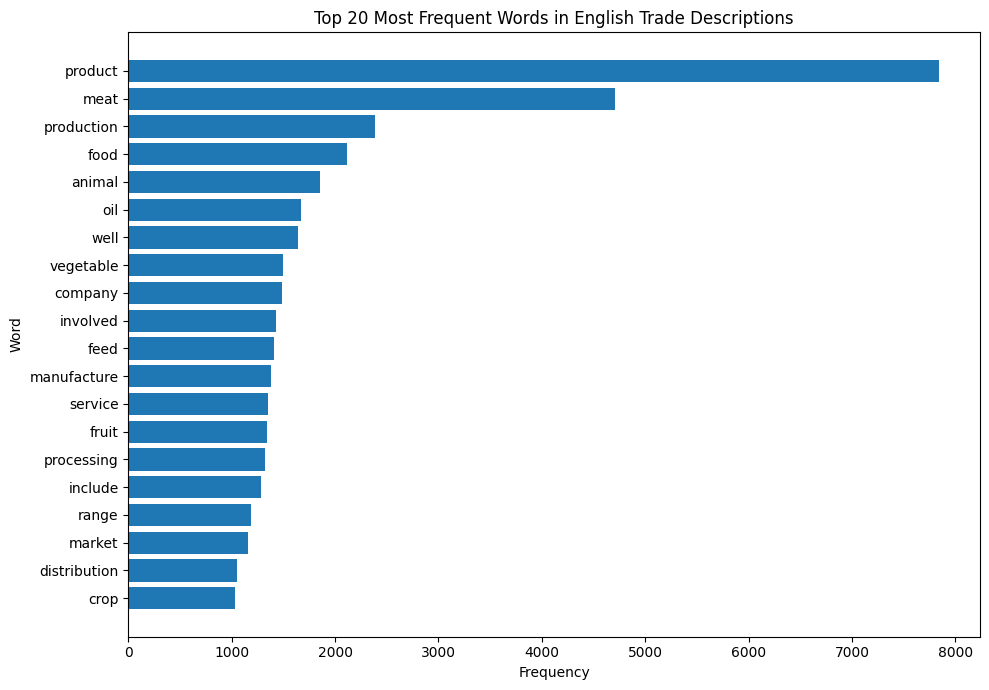

In [18]:
# --------------------------------------------------------
# Visualize the twenty most frequent words
# in the English trade descriptions
# --------------------------------------------------------

plt.figure(figsize=(10,7))

plt.barh(
    top20_population["Word"],
    top20_population["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.title("Top 20 Most Frequent Words in English Trade Descriptions")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [19]:
companies_df["English trade description"].notna().sum()

np.int64(4457)

## Word Cloud

A word cloud is generated to provide a visual representation of the most frequently occurring words in the English trade descriptions.

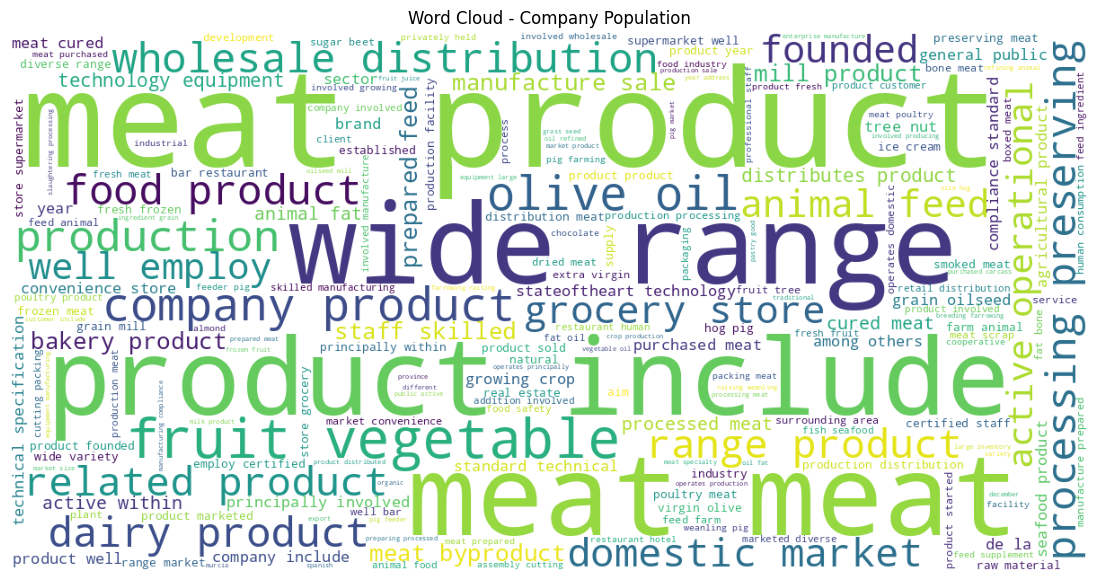

In [20]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(population_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Company Population")

plt.show()

# 12. Bag-of-Words Representation of English Trade Descriptions

The Bag-of-Words (BoW) model is one of the fundamental techniques in Natural Language Processing (NLP). It represents a collection of text documents as a matrix of word frequencies, where each row corresponds to a document and each column corresponds to a unique term in the vocabulary.

Unlike the previous frequency analysis, which provides an overall count of the most common words across the dataset, the Bag-of-Words model preserves the occurrence of each term within individual trade descriptions. This representation serves as the foundation for many NLP applications, including document classification, clustering, and text similarity analysis.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# ------------------------------------------------------------
# Build the Bag-of-Words representation
# ------------------------------------------------------------

bow_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

bow_matrix = bow_vectorizer.fit_transform(
    nlp_df["Cleaned_Description"]
)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

# Total frequency of each term
bow_frequency = bow_df.sum().sort_values(ascending=False)

display(
    bow_frequency.reset_index().rename(
        columns={
            "index": "Term",
            0: "Frequency"
        }
    )
)

,Term,Frequency
0,product,7848
1,meat,4708
2,production,2385
3,food,2115
4,animal,1851
5,oil,1674
6,company,1514
7,vegetable,1499
8,involved,1432
9,feed,1404


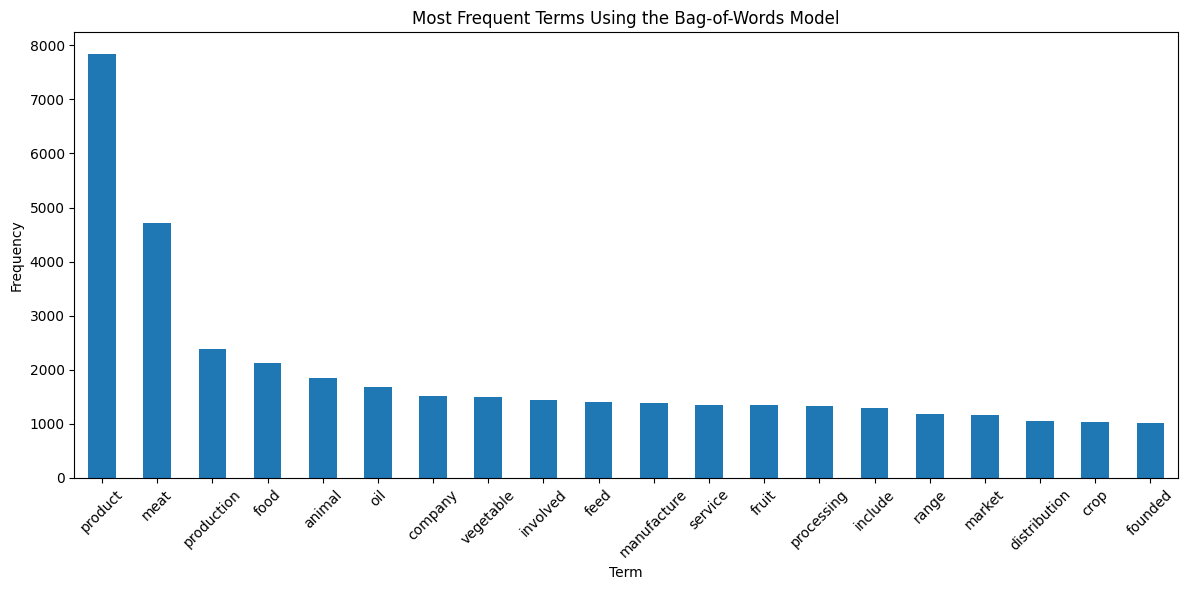

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bow_frequency.plot(kind="bar")

plt.title("Most Frequent Terms Using the Bag-of-Words Model")

plt.xlabel("Term")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

Bag-of-Words Analysis of English Trade Descriptionsconfirms the vocabulary that characterizes the English trade descriptions by quantifying the occurrence of each term across the dataset. The most frequent words correspond to the principal products, services, and business activities described by the companies.

Although the Bag-of-Words model does not consider word order or semantic relationships, it provides a structured numerical representation of textual data. This representation constitutes a fundamental feature extraction technique in NLP and serves as the basis for more advanced methods such as TF-IDF weighting, document classification, clustering, and topic modelling.

# 13. TF-IDF Analysis of English Trade Descriptions

While the Bag-of-Words model represents documents using raw word frequencies, Term Frequency–Inverse Document Frequency (TF-IDF) assigns a weight to each term according to both its frequency within a document and its rarity across the entire corpus.

Consequently, words that appear frequently in a particular trade description but are uncommon in other descriptions receive higher TF-IDF scores. This weighting reduces the influence of very common terms and highlights the most informative words describing companies' business activities.

TF-IDF is one of the most widely used feature extraction techniques in Natural Language Processing and is frequently employed in document classification, clustering, information retrieval, and topic modelling.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# ------------------------------------------------------------
# Build the TF-IDF representation
# ------------------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    nlp_df["Cleaned_Description"]
)

# Compute the average TF-IDF score of each term
tfidf_scores = pd.DataFrame({
    "Term": tfidf_vectorizer.get_feature_names_out(),
    "Average_TFIDF": tfidf_matrix.mean(axis=0).A1
})

tfidf_scores = (
    tfidf_scores
    .sort_values("Average_TFIDF", ascending=False)
    .head(20)
)

display(tfidf_scores)

,Term,Average_TFIDF
6855,meat,0.074665
8766,product,0.063983
562,animal,0.031520
4258,feed,0.029731
4515,food,0.029294
8767,production,0.028891
7634,oil,0.027769
11484,vegetable,0.025680
4670,fruit,0.025293
3008,crop,0.024053


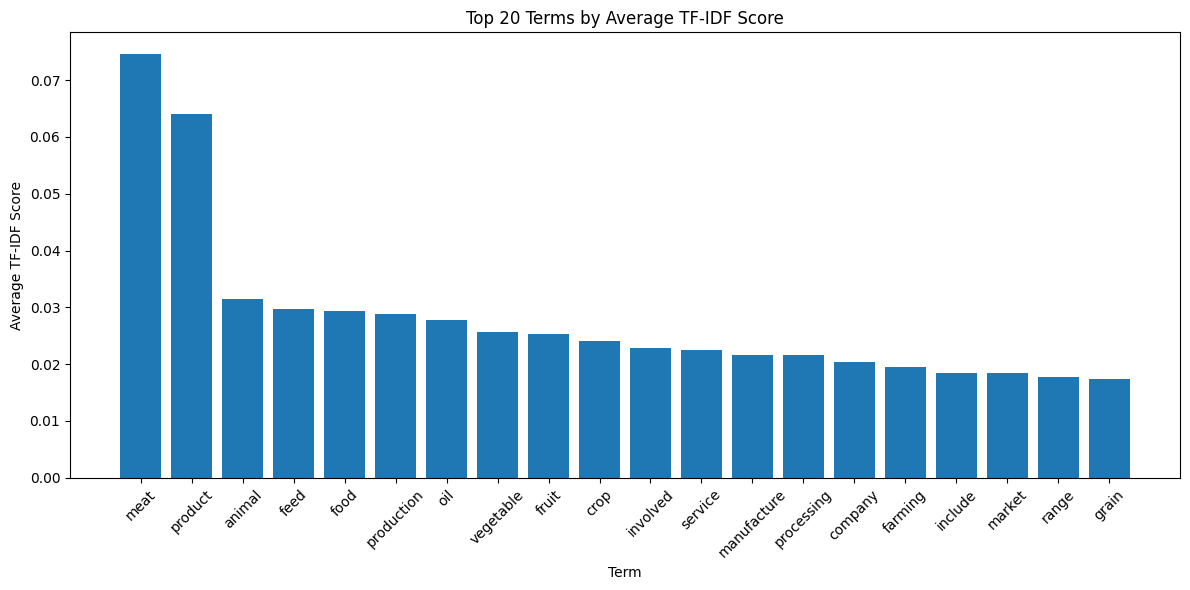

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    tfidf_scores["Term"],
    tfidf_scores["Average_TFIDF"]
)

plt.title("Top 20 Terms by Average TF-IDF Score")

plt.xlabel("Term")

plt.ylabel("Average TF-IDF Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

The TF-IDF analysis identifies the terms that are most informative across the English trade descriptions. Unlike raw frequency analysis, TF-IDF reduces the importance of words that appear frequently in many company descriptions and assigns higher weights to terms that better distinguish individual business activities.

The highest-ranked TF-IDF terms therefore provide a more representative characterization of the companies' products, services, and areas of specialization. This analysis complements both the frequency analysis and the Bag-of-Words representation by highlighting the vocabulary that carries the greatest descriptive value within the dataset.

# 14. Frequency Analysis by Import/Export Status

This section compares the vocabulary used by importing and exporting companies in their English trade descriptions. The analysis identifies the most frequently occurring terms within each group, providing insights into the dominant commercial activities associated with importers and exporters.

The comparison highlights similarities and differences in the language used to describe business operations.

In [ ]:
for col in population_df.columns:
    print(col)

Column1
Company name
Street
Postal code
Locality
Province
Autonomous community
Phone number
Web address
Tax ID Code
Legal form
Share capital (thousand EUR)
President
Executive Director
Quotes, doesn't quote, quoted
Last available year
Number of available years
Latest employee count
Stock Market Quote
Operating revenue (thousand EUR)
Nb of companies in corporate group
Number of investees
Primary CNAE 2009 code
Secondary code(s) CNAE 2009
Secondary literal(s) CNAE 2009
Primary CNAE 2009 code literal
Group name
Group Description
Group size
English trade description
Activity description
Importer / Exporter
Cleaned_Description
Word_Count
Character_Count


# 14.1. Frequency Analysis by Importer / Exporter Status

This section compares the vocabulary used by companies according to their international trade status. Companies are classified into four groups:

- No international trade activity
- Importers
- Exporters
- Importers and exporters

For each group, the most frequently occurring words are identified and visualized using horizontal bar charts.

In [ ]:
from collections import Counter

def plot_top_words(df, title, top_n=15):

    text = " ".join(df["Cleaned_Description"])

    words = text.split()

    counts = Counter(words)

    top_words = pd.DataFrame(
        counts.most_common(top_n),
        columns=["Word", "Frequency"]
    )

    plt.figure(figsize=(9,6))

    plt.barh(
        top_words["Word"],
        top_words["Frequency"]
    )

    plt.gca().invert_yaxis()

    plt.title(title)

    plt.xlabel("Frequency")

    plt.tight_layout()

    plt.show()

    return top_words

In [ ]:
no_trade = population_df[
    population_df["Importer / Exporter"] ==
    "No realiza actividad exterior"
]

importers = population_df[
    population_df["Importer / Exporter"] ==
    "Importador"
]

exporters = population_df[
    population_df["Importer / Exporter"] ==
    "Exportador"
]

both = population_df[
    population_df["Importer / Exporter"] ==
    "Importador / Exportador"
]

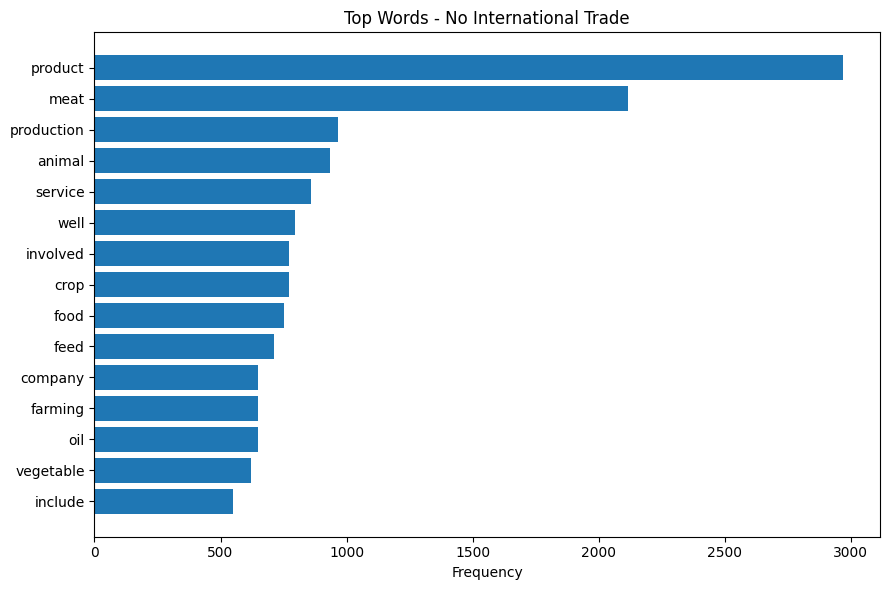

In [ ]:
top_no_trade = plot_top_words(
    no_trade,
    "Top Words - No International Trade"
)

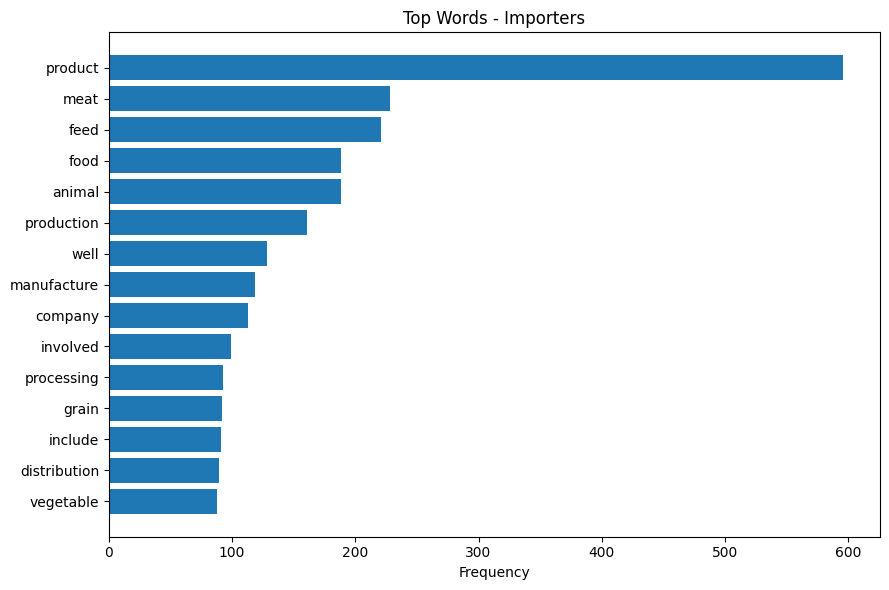

In [ ]:
top_importers = plot_top_words(
    importers,
    "Top Words - Importers"
)

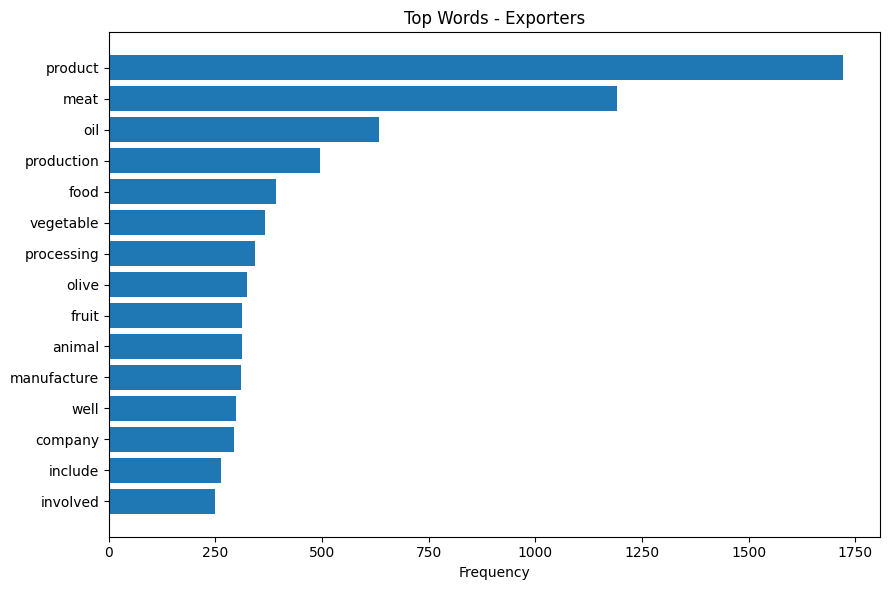

In [ ]:
top_exporters = plot_top_words(
    exporters,
    "Top Words - Exporters"
)

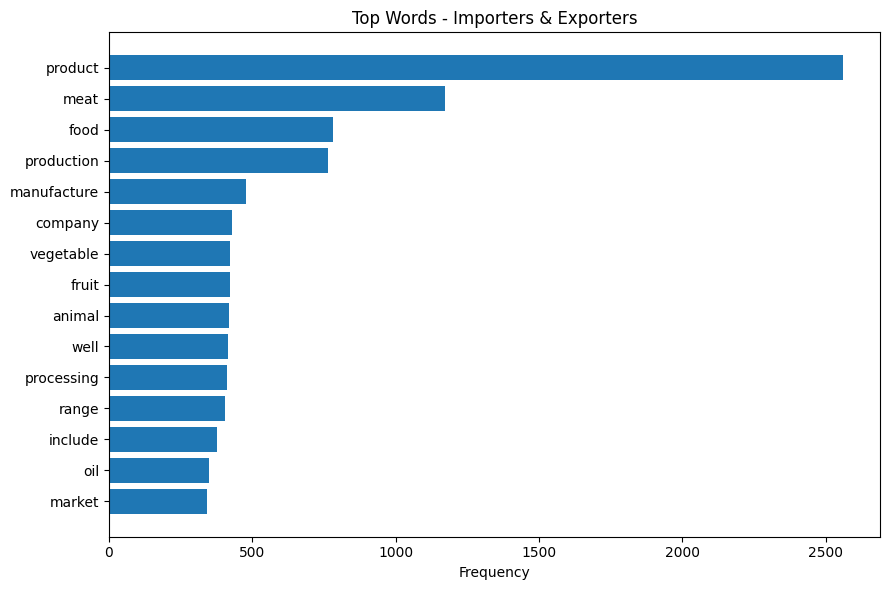

In [ ]:
top_both = plot_top_words(
    both,
    "Top Words - Importers & Exporters"
)

### Interpretation

The frequency analysis indicates that the vocabulary used in the English trade descriptions varies according to the companies' international trade status while sharing several common business-related terms. Across all four groups, the terms *product* and *meat* are the most frequently occurring, suggesting a strong representation of food-processing and agricultural businesses within the analyzed sample.

Companies without international trade activities emphasize terms such as *production*, *animal*, *service*, and *farming*, reflecting activities primarily oriented toward domestic markets. In contrast, importing companies frequently use words such as *manufacture*, *processing*, *distribution*, and *grain*, indicating greater involvement in industrial production and supply-chain activities.

Exporting companies show a stronger presence of terms including *oil*, *vegetable*, *olive*, and *fruit*, highlighting the importance of agricultural and food-related products in international markets. Companies engaged in both importing and exporting combine characteristics of both groups, with frequent references to *manufacture*, *food*, *processing*, *market*, and *vegetable*, suggesting more diversified commercial operations.

Overall, the frequency analysis demonstrates that although the business descriptions share a common vocabulary, internationally active firms exhibit a broader and more specialized terminology than companies operating exclusively in domestic markets.

# 15. Frequency Analysis by Activity Description

This section examines the vocabulary used by companies across different economic activities. The analysis begins by identifying the most frequently represented activity descriptions in the dataset. Subsequently, the English trade descriptions associated with these activities are analyzed to identify their most common terms.

The objective is to determine whether companies operating in different economic sectors employ distinct business terminology when describing their commercial activities.

### 15.1 Most Frequent Activity Descriptions

The ten most frequently occurring activity descriptions are identified in order to focus the analysis on the largest economic sectors represented in the database.

In [ ]:
# Top 10 activity descriptions

top_activities = (
    population_df["Activity description"]
    .value_counts()
    .head(10)
)

top_activities

,count
Activity description,
Fabricación y comercialización de aceite de oliva.,10
Fabricación de piensos.,8
Fabricación y envasado de aceite de oliva.,8
Cría y engorde de ganado porcino.,6
Fabricación de embutidos,6
Matadero de aves.,5
Fabricación y venta de aceite de oliva,5
Explotación de granja de ganado porcino.,5
Cría y engorde de ganado porcino,5


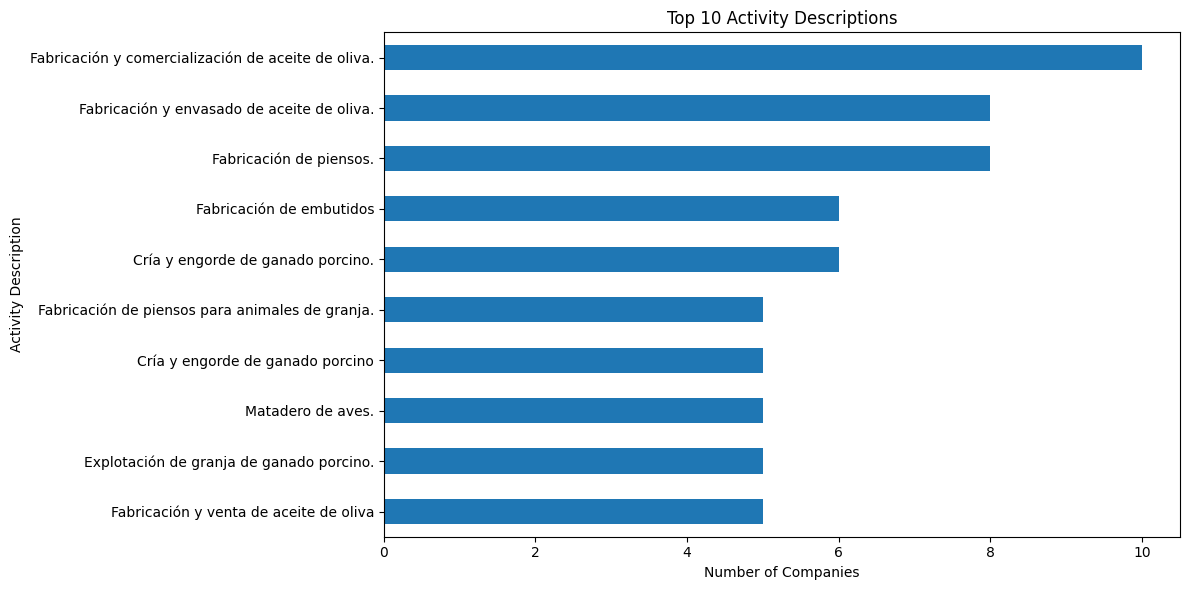

In [ ]:
plt.figure(figsize=(12,6))

top_activities.sort_values().plot(kind="barh")

plt.xlabel("Number of Companies")

plt.ylabel("Activity Description")

plt.title("Top 10 Activity Descriptions")

plt.tight_layout()

plt.show()

### Interpretation

The distribution of activity descriptions demonstrates a high degree of specialization among the companies included in the dataset. The most frequently occurring activity descriptions are represented by only a limited number of firms, with the largest category containing ten companies. This indicates that the database covers a wide variety of highly specific business activities rather than a small number of broad industrial sectors.

The most common activities are primarily related to the agri-food industry, including olive oil production, animal feed manufacturing, meat processing, pig farming, and poultry slaughtering. These activities reflect the economic importance of agricultural production and food processing within the analyzed company population.

The observed diversity suggests that companies employ highly specialized activity descriptions. Consequently, the subsequent NLP analyses focus on broader grouping variables, such as international trade status, province, and company size, which provide more representative comparisons across the population.

# 16. Frequency Analysis by Province

This section investigates the vocabulary used by companies across different provinces. By grouping companies according to their geographical location, the analysis aims to identify regional differences in the terminology used within the English trade descriptions.

The comparison provides an overview of the dominant economic activities represented in the principal provinces included in the database.

In [ ]:
top_provinces = (
    population_df["Province"]
    .value_counts()
    .head(10)
)

top_provinces

,count
Province,
Madrid,426
Barcelona,350
Murcia,328
Sevilla,239
Valencia,215
Girona,162
Navarra,152
Lleida,130
Badajoz,129


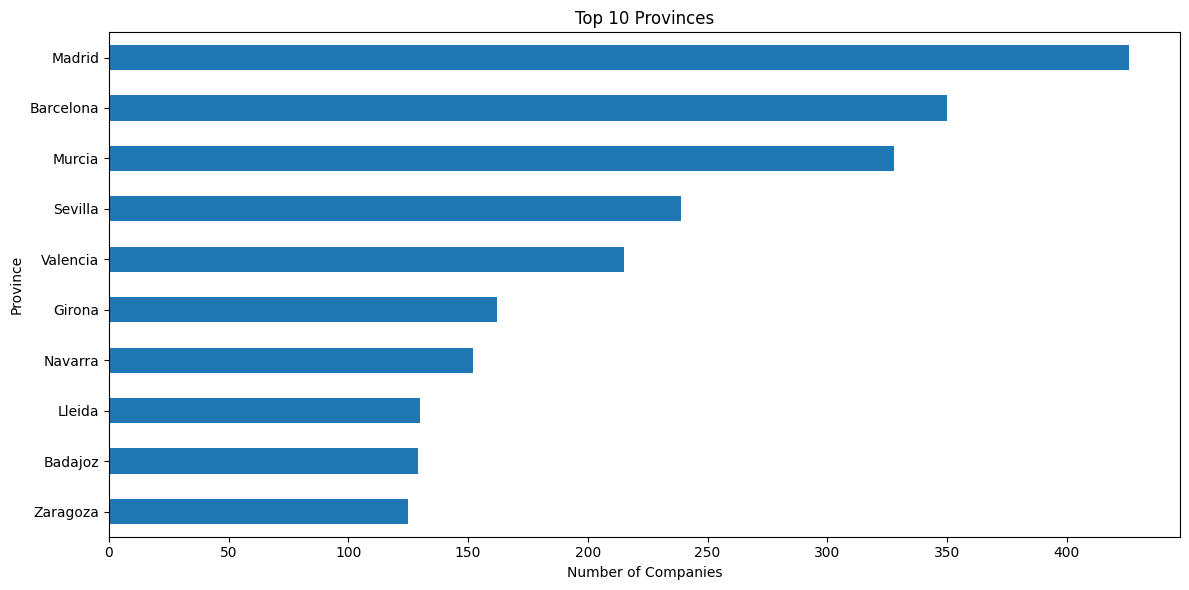

In [ ]:
plt.figure(figsize=(12,6))

top_provinces.sort_values().plot(kind="barh")

plt.xlabel("Number of Companies")

plt.ylabel("Province")

plt.title("Top 10 Provinces")

plt.tight_layout()

plt.show()

### Interpretation

The geographical distribution of companies is not uniform across the dataset. Madrid, Barcelona, and Murcia represent the provinces with the largest numbers of companies possessing English trade descriptions, followed by Sevilla and Valencia. These provinces therefore constitute the principal regional groups for the subsequent frequency analysis of the English trade descriptions.

## 16.2 Frequency Analysis of English Trade Descriptions by Province

To investigate potential regional differences in business terminology, the English trade descriptions are analyzed separately for the provinces with the largest numbers of companies. For each province, the most frequently occurring words are identified and visualized using horizontal bar charts.

In [ ]:
def province_frequency(province_name):

    subset = population_df[
        population_df["Province"] == province_name
    ]

    text = " ".join(
        subset["Cleaned_Description"]
    )

    words = text.split()

    counts = Counter(words)

    top_words = pd.DataFrame(
        counts.most_common(15),
        columns=["Word","Frequency"]
    )

    plt.figure(figsize=(8,6))

    plt.barh(
        top_words["Word"],
        top_words["Frequency"]
    )

    plt.gca().invert_yaxis()

    plt.title(f"Top Words - {province_name}")

    plt.xlabel("Frequency")

    plt.tight_layout()

    plt.show()

    return top_words

In [ ]:
top5_provinces = top_provinces.head(5)

Madrid


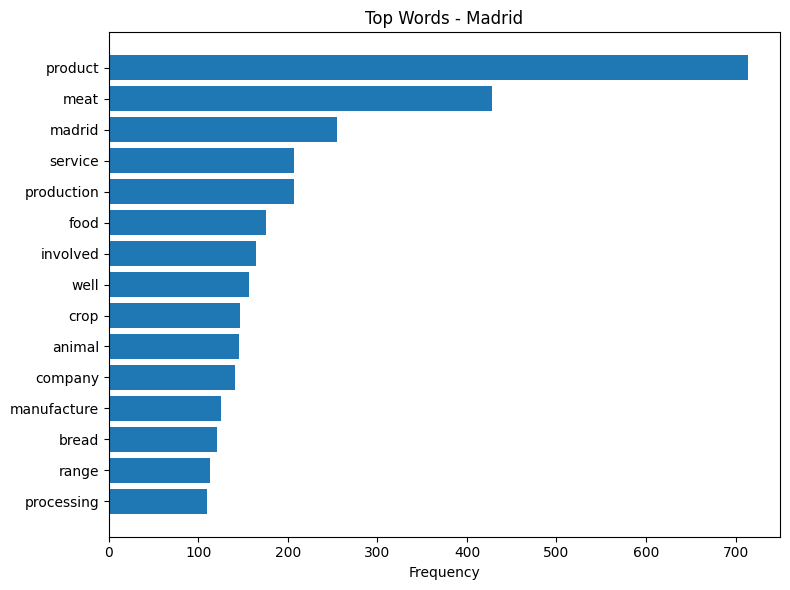

,Word,Frequency
0,product,714
1,meat,428
2,madrid,255
3,service,207
4,production,207
5,food,175
6,involved,164
7,well,156
8,crop,146
9,animal,145


Barcelona


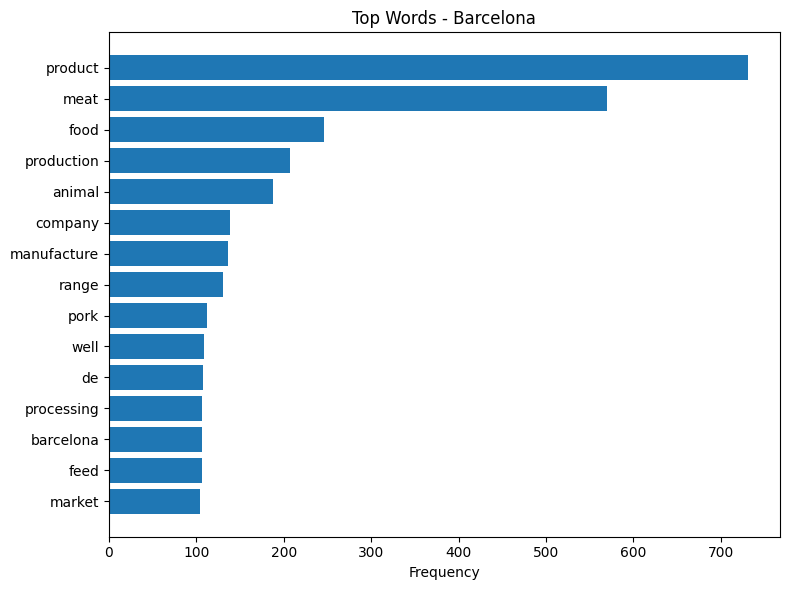

,Word,Frequency
0,product,731
1,meat,570
2,food,246
3,production,207
4,animal,188
5,company,138
6,manufacture,136
7,range,130
8,pork,112
9,well,109


Murcia


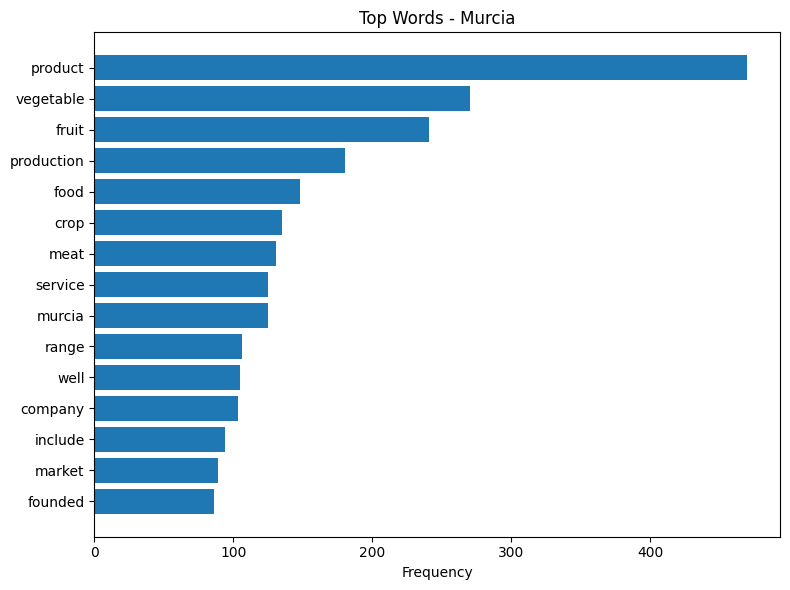

,Word,Frequency
0,product,470
1,vegetable,270
2,fruit,241
3,production,180
4,food,148
5,crop,135
6,meat,131
7,service,125
8,murcia,125
9,range,106


Sevilla


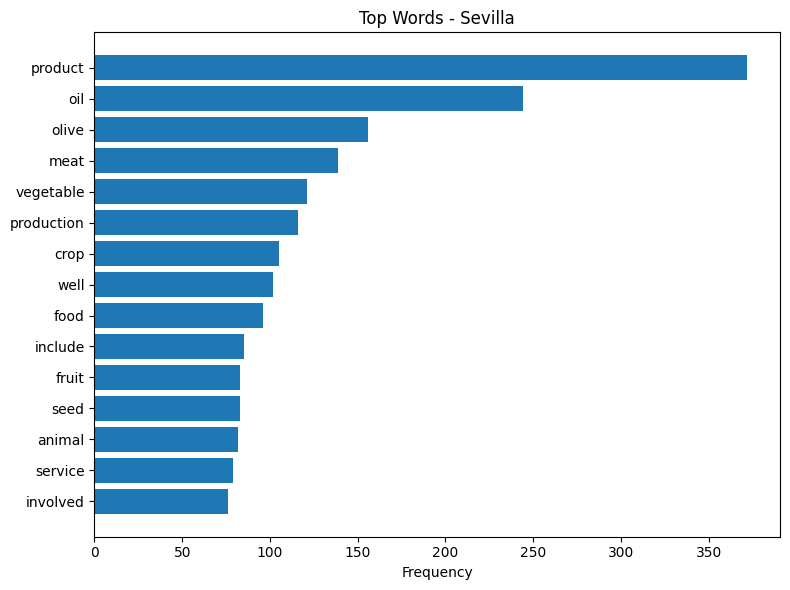

,Word,Frequency
0,product,372
1,oil,244
2,olive,156
3,meat,139
4,vegetable,121
5,production,116
6,crop,105
7,well,102
8,food,96
9,include,85


Valencia


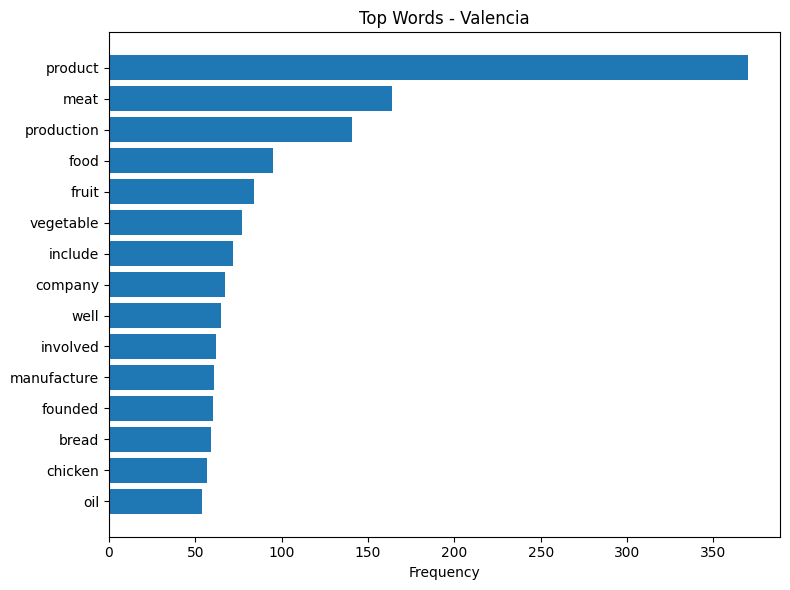

,Word,Frequency
0,product,370
1,meat,164
2,production,141
3,food,95
4,fruit,84
5,vegetable,77
6,include,72
7,company,67
8,well,65
9,involved,62


In [ ]:
for province in top5_provinces.index:

    print("="*80)

    print(province)

    print("="*80)

    display(
        province_frequency(province)
    )

### Interpretation

The frequency analysis of the English trade descriptions across the principal provinces reveals both common and region-specific business characteristics. Across all provinces, terms such as *product*, *production*, *food*, and *manufacture* appear frequently, indicating that manufacturing and agri-food activities constitute an important component of the business landscape represented in the database.

Some regional differences are also evident. Provinces such as Valencia and Murcia display a stronger presence of terms related to agricultural production, including *fruit*, *vegetable*, and *oil*, reflecting their well-established agricultural and food-processing sectors. In contrast, provinces with larger and more diversified economies, such as Madrid and Barcelona, exhibit a broader business vocabulary associated with manufacturing, commercial products, and industrial activities.

Overall, the analysis suggests that while companies across different provinces share a common business vocabulary, the English trade descriptions also reflect the dominant economic activities characterizing each geographical region. These findings provide a descriptive overview of the regional specialization of companies before examining the sentiment associated with their trade descriptions.

# Summary of Findings

This notebook presented a descriptive Natural Language Processing (NLP) analysis of the English trade descriptions contained in the company dataset. The analysis began with data inspection and quality assessment, followed by text preprocessing and cleaning to prepare the descriptions for subsequent NLP tasks.

Several descriptive NLP techniques were then applied to characterize the textual corpus. Word frequency analysis and word clouds provided an overview of the most commonly occurring terms, while the Bag-of-Words representation transformed the textual data into a structured numerical format suitable for computational analysis. Furthermore, TF-IDF feature extraction highlighted the most informative terms by reducing the influence of frequently occurring words and emphasizing vocabulary that better distinguishes individual business activities.

Finally, comparative lexical analyses across import/export status, activity description, and province provided additional insights into the distribution of business-related terminology within the dataset. Together, these analyses offer an exploratory understanding of the companies' trade descriptions and establish a solid descriptive foundation for subsequent NLP applications.

This notebook represents the descriptive stage of the overall NLP workflow. More advanced NLP techniques, including transformer-based ESG classification (Notebook 06) and BERTopic topic modelling (Notebook 07), are presented separately to provide a modular and progressively more sophisticated analysis of sustainability-related corporate text.